<a href="https://colab.research.google.com/github/Suhamyds/banco23-analise-risco/blob/main/Financial_Behavior_Intelligence_TEMA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Projeto Hackthon Grupo 23 – Diagnóstico de Saúde Financeira da Carteira de Clientes**

**Empresa: Banco23**

**Relatório**

A área de Negócios do Banco23 identificou que o modelo tradicional de análise de crédito (baseado apenas no Score) pode ser falha. Temos clientes com "nome limpo" que estão perdendo o fôlego financeiro silenciosamente.

Como equipe de Dados, nossa missão foi desenvolver o Índice de Resiliência Banco23, um modelo preditivo que antecipa o risco de crédito antes mesmo do Score de mercado oscilar. Este índice não analisa apenas o que o cliente é (Score), mas sim como ele se comporta (Comprometimento e Resiliência).

**As 4 Perguntas Fundamentais que guiaram nossa análise:**

1- A Armadilha da Renda Alta: Ter um salário alto é garantia de tranquilidade financeira ou esses clientes estão em risco tanto quanto os de baixa renda?

2- O Paradoxo do Score: Um Score de 700+ realmente significa que o cliente tem o orçamento sob controle?

3- O Teste de Estresse (Resiliência): Se a inflação subir amanhã, quais clientes serão os primeiros a parar de poupar e entrar na zona de inadimplência?

4- A Zona de Fronteira: Quem são os clientes "Equilibristas" que hoje parecem seguros, mas estão a apenas um passo (2%) de se tornarem um risco para o banco?




**Membros do Grupo:**

Amanda Castro (scastroamanda@hotmail.com)

Anelise Barros (annebarros00@gmail.com)

Jeanne Caputo (jeanne.caputo@gmail.com)

Renata Aires (renataaires8332@gmail.com)

Suhamyds Lays A de O Moraes (Suhamydslays@gmail.com)

In [ ]:
# ============================================
# FINANCIAL BEHAVIOR INTELLIGENCE
# Hackathon Dados - GRUPO 23
#
# ============================================

print("Iniciando configuração do ambiente.")

!pip install pandas numpy matplotlib seaborn kagglehub -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import sqlite3
import matplotlib.pyplot as plt
from datetime import datetime

print ("Bibliotecas instaladas e importadas com sucesso")
print (f" Data da execução: {datetime.now().strftime('%d/%m/%Y %H:%M')}")

Iniciando configuração do ambiente.
Bibliotecas instaladas e importadas com sucesso
 Data da execução: 08/05/2026 14:50


In [ ]:
print("Baixando dataset do Kaggle")
path = kagglehub.dataset_download("khushikyad001/personal-finance-tracker-dataset")
print(f"Dataset baixado em : {path}")
print(f"\n Arquivos disponíveis:")
print(os.listdir(path))
df = pd.read_csv(os.path.join(path, 'personal_finance_tracker_dataset.csv'))
print(f"\n Dataset carregado com sucesso!")
print(f" Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")

Baixando dataset do Kaggle


100%|██████████| 169k/169k [00:00<00:00, 19.8MB/s]

Extracting files...
Dataset baixado em : /root/.cache/kagglehub/datasets/khushikyad001/personal-finance-tracker-dataset/versions/1

 Arquivos disponíveis:
['personal_finance_tracker_dataset.csv']

 Dataset carregado com sucesso!
 Dimensões: 3000 linhas × 25 colunas


In [ ]:
# ANÁLISE EXPLORATÓRIA INICIAL

print("="*60)
print(" ANÁLISE EXPLORATÓRIA INICIAL")
print("="*60)

print("\n PRIMEIRAS 5 LINHAS:")
display(df.head())

print("\n ÚLTIMAS 5 LINHAS:")
display(df.tail())

print("\n COLUNAS DO DATASET:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

print("\n TIPOS DE DADOS:")
print(df.dtypes)

print("\n ESTATÍSTICAS DESCRITIVAS BÁSICAS:")
display(df.describe())

print("\n❌ VALORES NULOS:")
print(df.isnull().sum())

 ANÁLISE EXPLORATÓRIA INICIAL

 PRIMEIRAS 5 LINHAS:


,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,...,discretionary_spending,essential_spending,income_type,rent_or_mortgage,category,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met
0,2019-01-01,1584,3119.58,3212.07,0.38,3676.11,inflation,721.0,0.56,125.77,...,857.55,1910.85,Freelance,1501.65,Investments,Positive,8.3,Low,0.00,0
1,2019-01-31,1045,3262.44,3732.81,0.10,2607.17,inflation,670.0,0.42,454.19,...,534.51,3165.20,Salary,1603.17,Investments,Positive,22.6,Low,0.00,0
2,2019-03-02,1756,2931.20,3335.58,0.15,3004.14,inflation,691.0,0.24,971.82,...,353.67,1504.56,Freelance,1097.82,Healthcare,Positive,58.8,Low,0.00,0
3,2019-04-01,1724,3506.79,2327.59,0.17,3346.97,normal,717.0,0.16,482.76,...,594.08,1450.72,Freelance,1155.64,Groceries,Positive,74.5,Low,1179.20,0
4,2019-05-01,1600,4606.87,2182.58,0.34,2670.09,inflation,795.0,0.25,263.74,...,556.86,1000.00,Salary,1170.86,Utilities,Negative,38.7,High,2424.29,0



 ÚLTIMAS 5 LINHAS:


,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,...,discretionary_spending,essential_spending,income_type,rent_or_mortgage,category,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met
2995,2023-07-09,1822,3254.55,3992.02,0.17,2675.77,normal,704.0,0.30,285.16,...,408.23,2088.32,Mixed,2079.99,Healthcare,Positive,43.2,Low,0.00,0
2996,2023-08-08,1907,2752.78,5685.18,0.26,2682.99,recession,697.0,0.12,417.06,...,167.78,2445.34,Salary,832.95,Entertainment,Neutral,46.0,Low,0.00,0
2997,2023-09-07,1464,3691.10,3228.05,0.12,3893.53,normal,626.0,0.12,621.01,...,275.53,3231.56,Salary,790.68,Utilities,Neutral,40.7,Medium,463.05,0
2998,2023-10-07,1346,3133.24,4335.72,0.08,2854.72,inflation,628.0,0.42,650.23,...,373.85,2305.14,Salary,903.82,Utilities,Positive,57.1,Low,0.00,0
2999,2023-11-06,1140,4090.06,3546.83,0.23,2365.61,normal,655.0,0.46,117.15,...,695.36,3142.37,Salary,316.24,Entertainment,Positive,54.8,Low,543.23,0



 COLUNAS DO DATASET:
   1. date
   2. user_id
   3. monthly_income
   4. monthly_expense_total
   5. savings_rate
   6. budget_goal
   7. financial_scenario
   8. credit_score
   9. debt_to_income_ratio
   10. loan_payment
   11. investment_amount
   12. subscription_services
   13. emergency_fund
   14. transaction_count
   15. fraud_flag
   16. discretionary_spending
   17. essential_spending
   18. income_type
   19. rent_or_mortgage
   20. category
   21. cash_flow_status
   22. financial_advice_score
   23. financial_stress_level
   24. actual_savings
   25. savings_goal_met

 TIPOS DE DADOS:
date                       object
user_id                     int64
monthly_income            float64
monthly_expense_total     float64
savings_rate              float64
budget_goal               float64
financial_scenario         object
credit_score              float64
debt_to_income_ratio      float64
loan_payment              float64
investment_amount         float64
subscription_service

,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,credit_score,debt_to_income_ratio,loan_payment,investment_amount,subscription_services,emergency_fund,transaction_count,fraud_flag,discretionary_spending,essential_spending,rent_or_mortgage,financial_advice_score,actual_savings,savings_goal_met
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1498.699000,4004.267347,3011.682230,0.225897,2811.070463,679.923667,0.350817,508.58113,400.610493,4.975000,1005.349830,59.529333,0.023667,500.810990,2215.587100,1211.897797,50.071133,1156.418457,0.092333
std,287.352782,1000.107096,801.151864,0.101417,490.855344,49.970847,0.145191,199.44458,235.361273,2.559536,485.780881,23.101610,0.152034,199.800377,596.267983,400.482024,29.087360,1039.597384,0.289544
min,1000.000000,685.280000,159.210000,0.050000,1175.570000,515.000000,0.100000,0.00000,0.000000,1.000000,0.000000,20.000000,0.000000,0.000000,1000.000000,300.000000,0.100000,0.000000,0.000000
25%,1248.750000,3362.250000,2473.205000,0.140000,2481.957500,646.000000,0.220000,375.34000,234.780000,3.000000,674.012500,38.750000,0.000000,361.562500,1807.235000,933.530000,25.100000,144.965000,0.000000
50%,1496.500000,4008.075000,3023.810000,0.230000,2822.285000,679.000000,0.350000,508.57000,388.075000,5.000000,1010.485000,60.000000,0.000000,496.340000,2215.705000,1213.605000,48.700000,1032.810000,0.000000
75%,1749.000000,4659.040000,3555.502500,0.310000,3131.000000,713.000000,0.480000,638.47000,559.842500,7.000000,1337.820000,79.000000,0.000000,640.105000,2624.675000,1482.860000,76.100000,1821.510000,0.000000
max,1999.000000,7407.940000,5853.200000,0.400000,4386.500000,847.000000,0.600000,1176.88000,1292.300000,9.000000,2585.360000,99.000000,1.000000,1158.740000,4245.900000,2614.620000,100.000000,6589.660000,1.000000



❌ VALORES NULOS:
date                      0
user_id                   0
monthly_income            0
monthly_expense_total     0
savings_rate              0
budget_goal               0
financial_scenario        0
credit_score              0
debt_to_income_ratio      0
loan_payment              0
investment_amount         0
subscription_services     0
emergency_fund            0
transaction_count         0
fraud_flag                0
discretionary_spending    0
essential_spending        0
income_type               0
rent_or_mortgage          0
category                  0
cash_flow_status          0
financial_advice_score    0
financial_stress_level    0
actual_savings            0
savings_goal_met          0
dtype: int64


In [ ]:
# DICIONÁRIO DE DADOS

print("="*60)
print("DICIONÁRIO DE DADOS")
print("="*60)

colunas_dict = {
    'user_id': 'Identificador único do usuário',
    'month_of_year': 'Mês e ano da observação (YYYY-MM)',
    'monthly_income': 'Renda mensal do usuário (USD)',
    'total_expenses': 'Despesas totais mensais (USD)',
    'savings_ratio': 'Proporção da renda poupada (0 a 1)',
    'credit_score': 'Score de crédito (300 a 850)',
    'debt_to_income_ratio': 'Relação dívida/renda (0 a 1)',
    'monthly_loan_repayment': 'Pagamento mensal de empréstimos (USD)',
    'economic_state': 'Cenário econômico: normal/inflation/recession',
    'financial_stress': 'Nível de estresse financeiro (Low/Medium/High)'
}

for coluna, descricao in colunas_dict.items():
    if coluna in df.columns:
        print(f"\n🔹 {coluna}:")
        print(f"   Descrição: {descricao}")
        print(f"   Valores únicos: {df[coluna].nunique()}")
        print(f"   Exemplo: {df[coluna].iloc[0]}")

DICIONÁRIO DE DADOS

🔹 user_id:
   Descrição: Identificador único do usuário
   Valores únicos: 944
   Exemplo: 1584

🔹 monthly_income:
   Descrição: Renda mensal do usuário (USD)
   Valores únicos: 2985
   Exemplo: 3119.58

🔹 credit_score:
   Descrição: Score de crédito (300 a 850)
   Valores únicos: 264
   Exemplo: 721.0

🔹 debt_to_income_ratio:
   Descrição: Relação dívida/renda (0 a 1)
   Valores únicos: 51
   Exemplo: 0.56


In [ ]:
# LEITURA DO ARQUIVO DE BASE.

df_raw = df.copy()

df_raw.to_csv('dataset_original.csv', index=False)
print("Dataset original salvo como 'dataset_original.csv'")

tamanho = os.path.getsize('dataset_original.csv') / 1024
print(f"Tamanho do arquivo: {tamanho:.1f} KB")

print("\n" + "="*60)
#print("DIA 1 CONCLUÍDO COM SUCESSO!")
print("="*60)
#print("\n Atividades realizadas hoje:")
#print("   1. Criado e compartilhado Google Colab da equipe")
#print("   2. Baixado o dataset Personal Finance Tracker")
print("   3. Realizada análise exploratória inicial")
print("   4. Documentadas as colunas do dataset")
print("   5. Salvo dataset original para uso futuro")
#print("\n PRÓXIMO PASSO (Dia 2):")
#print("   - Limpeza de dados")
#print("   - Feature engineering")
#print("   - Queries SQL")

Dataset original salvo como 'dataset_original.csv'
Tamanho do arquivo: 468.6 KB

   3. Realizada análise exploratória inicial
   4. Documentadas as colunas do dataset
   5. Salvo dataset original para uso futuro


In [ ]:
# TRATAMENTO DE DATAS

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month


**Conexão com banco de dados via SQLite3.**

Limpeza dos dados.

In [ ]:
# CRIAÇÃO DA CONEXÃO COM O BANCO DE DADOS

conn = sqlite3.connect('finance_data.db')

# Salvar o DataFrame 'df' no banco de dados SQLite

df.to_sql('tb_clientes_cartao', conn, if_exists='replace', index=False)
print("Tabela 'tb_clientes_cartao' criada e populada no banco de dados.")

query_consulta = "SELECT * FROM tb_clientes_cartao"


df_final = pd.read_sql(query_consulta, conn)


print("\nPrimeiras 5 linhas de df_final:")
df_final.head()

Tabela 'tb_clientes_cartao' criada e populada no banco de dados.

Primeiras 5 linhas de df_final:


,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,...,income_type,rent_or_mortgage,category,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met,year,month
0,2019-01-01 00:00:00,1584,3119.58,3212.07,0.38,3676.11,inflation,721.0,0.56,125.77,...,Freelance,1501.65,Investments,Positive,8.3,Low,0.00,0,2019,1
1,2019-01-31 00:00:00,1045,3262.44,3732.81,0.10,2607.17,inflation,670.0,0.42,454.19,...,Salary,1603.17,Investments,Positive,22.6,Low,0.00,0,2019,1
2,2019-03-02 00:00:00,1756,2931.20,3335.58,0.15,3004.14,inflation,691.0,0.24,971.82,...,Freelance,1097.82,Healthcare,Positive,58.8,Low,0.00,0,2019,3
3,2019-04-01 00:00:00,1724,3506.79,2327.59,0.17,3346.97,normal,717.0,0.16,482.76,...,Freelance,1155.64,Groceries,Positive,74.5,Low,1179.20,0,2019,4
4,2019-05-01 00:00:00,1600,4606.87,2182.58,0.34,2670.09,inflation,795.0,0.25,263.74,...,Salary,1170.86,Utilities,Negative,38.7,High,2424.29,0,2019,5


In [ ]:
# SELEÇÃO DE COLUNAS COM ESPAÇOS NO ID

query_espacos = """
SELECT *
FROM tb_clientes_cartao
WHERE user_id LIKE ' %' OR user_id LIKE '% '
"""
df_check_sql = pd.read_sql(query_espacos, conn)

# DATAFRAME COMPLETO

print(f"Total de registros com erro: {len(df_check_sql)}")
print(df_check_sql.head())

Total de registros com erro: 0
Empty DataFrame
Columns: [date, user_id, monthly_income, monthly_expense_total, savings_rate, budget_goal, financial_scenario, credit_score, debt_to_income_ratio, loan_payment, investment_amount, subscription_services, emergency_fund, transaction_count, fraud_flag, discretionary_spending, essential_spending, income_type, rent_or_mortgage, category, cash_flow_status, financial_advice_score, financial_stress_level, actual_savings, savings_goal_met, year, month]
Index: []

[0 rows x 27 columns]


In [ ]:
# VISUALIZAÇÃO DAS INFORMAÇÕES DO DATAFRAME

df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    3000 non-null   object 
 1   user_id                 3000 non-null   int64  
 2   monthly_income          3000 non-null   float64
 3   monthly_expense_total   3000 non-null   float64
 4   savings_rate            3000 non-null   float64
 5   budget_goal             3000 non-null   float64
 6   financial_scenario      3000 non-null   object 
 7   credit_score            3000 non-null   float64
 8   debt_to_income_ratio    3000 non-null   float64
 9   loan_payment            3000 non-null   float64
 10  investment_amount       3000 non-null   float64
 11  subscription_services   3000 non-null   int64  
 12  emergency_fund          3000 non-null   float64
 13  transaction_count       3000 non-null   int64  
 14  fraud_flag              3000 non-null   

In [ ]:
# VERIFICAÇÃO DE OUTLIERS

print("\n📊 ESTATÍSTICAS PARA DETECTAR OUTLIERS:")
colunas_numericas = df.select_dtypes(include=[np.number]).columns
for col in colunas_numericas[:5]:  # Mostra só as 5 primeiras
    print(f"\n   {col}:")
    print(f"      Mínimo: {df[col].min()}")
    print(f"      Máximo: {df[col].max()}")
    print(f"      Média: {df[col].mean():.2f}")
    print(f"      Desvio Padrão: {df[col].std():.2f}")


📊 ESTATÍSTICAS PARA DETECTAR OUTLIERS:

   user_id:
      Mínimo: 1000
      Máximo: 1999
      Média: 1498.70
      Desvio Padrão: 287.35

   monthly_income:
      Mínimo: 685.28
      Máximo: 7407.94
      Média: 4004.27
      Desvio Padrão: 1000.11

   monthly_expense_total:
      Mínimo: 159.21
      Máximo: 5853.2
      Média: 3011.68
      Desvio Padrão: 801.15

   savings_rate:
      Mínimo: 0.05
      Máximo: 0.4
      Média: 0.23
      Desvio Padrão: 0.10

   budget_goal:
      Mínimo: 1175.57
      Máximo: 4386.5
      Média: 2811.07
      Desvio Padrão: 490.86


In [ ]:
# DEFINIÇÃO DA LISTA COM NOMES DAS COLUNAS

colunas_financeiras = [
    'monthly_income', 'monthly_expense_total', 'savings_rate',
    'budget_goal', 'credit_score', 'debt_to_income_ratio',
    'loan_payment', 'investment_amount', 'emergency_fund',
    'discretionary_spending', 'essential_spending', 'rent_or_mortgage',
    'actual_savings'
]

# Loop de verificação
for col in colunas_financeiras:

    if col in df.columns: # Alterado de df_origem para df
        total_negativos = (df[col] < 0).sum() # Alterado de df_origem para df
        if total_negativos > 0:
            print(f"⚠️ A coluna '{col}' possui {total_negativos} valores negativos.")
        else:
            print(f"✅ A coluna '{col}' está limpa (sem negativos).")

✅ A coluna 'monthly_income' está limpa (sem negativos).
✅ A coluna 'monthly_expense_total' está limpa (sem negativos).
✅ A coluna 'savings_rate' está limpa (sem negativos).
✅ A coluna 'budget_goal' está limpa (sem negativos).
✅ A coluna 'credit_score' está limpa (sem negativos).
✅ A coluna 'debt_to_income_ratio' está limpa (sem negativos).
✅ A coluna 'loan_payment' está limpa (sem negativos).
✅ A coluna 'investment_amount' está limpa (sem negativos).
✅ A coluna 'emergency_fund' está limpa (sem negativos).
✅ A coluna 'discretionary_spending' está limpa (sem negativos).
✅ A coluna 'essential_spending' está limpa (sem negativos).
✅ A coluna 'rent_or_mortgage' está limpa (sem negativos).
✅ A coluna 'actual_savings' está limpa (sem negativos).


In [ ]:
# VERIFICAÇÃO DE VALORES DUPLICADOS

total_duplicados = df.duplicated().sum()
print(f"Total de linhas duplicadas: {total_duplicados}")

Total de linhas duplicadas: 0


## **Análise exploratória**

In [ ]:
# TAXA DE COMPROMETIMENTO DE RENDA

if 'monthly_expense_total' in df.columns and 'monthly_income' in df.columns:
    df['income_commitment_ratio'] = (df['monthly_expense_total'] / df['monthly_income']) * 100
    print("✓ Criado: income_commitment_ratio (Comprometimento de renda em %)")
    print(f"   Exemplo: {df['income_commitment_ratio'].iloc[0]:.1f}%")

✓ Criado: income_commitment_ratio (Comprometimento de renda em %)
   Exemplo: 103.0%


In [ ]:
# SALDO FINANCEIRO (RENDA - DESPESAS)

if 'monthly_income' in df.columns and 'monthly_expense_total' in df.columns:
    df['monthly_balance'] = df['monthly_income'] - df['monthly_expense_total']
    print("✓ Criado: monthly_balance (Saldo mensal)")
    print(f"   Exemplo: R$ {df['monthly_balance'].iloc[0]:.2f}")

✓ Criado: monthly_balance (Saldo mensal)
   Exemplo: R$ -92.49


"Qual a real saúde da nossa carteira hoje?"

O volume de clientes em cada categoria (Baixo, Médio, Alto e Extremo

In [ ]:
# CLASSIFICAÇÃO DE RISCO (Baseada em comprometimento da renda)

def classify_risk(commitment):
    if commitment < 30:
        return 'Baixo Risco'
    elif commitment < 50:
        return 'Médio Risco'
    elif commitment < 70:
        return 'Alto Risco'
    else:
        return 'Risco Extremo'

if 'income_commitment_ratio' in df.columns:
    df['risk_category'] = df['income_commitment_ratio'].apply(classify_risk)
    print("✓ Criado: risk_category (Categorias de risco)")
    print(f"   Categorias: {df['risk_category'].unique()}")

✓ Criado: risk_category (Categorias de risco)
   Categorias: ['Risco Extremo' 'Alto Risco' 'Médio Risco' 'Baixo Risco']


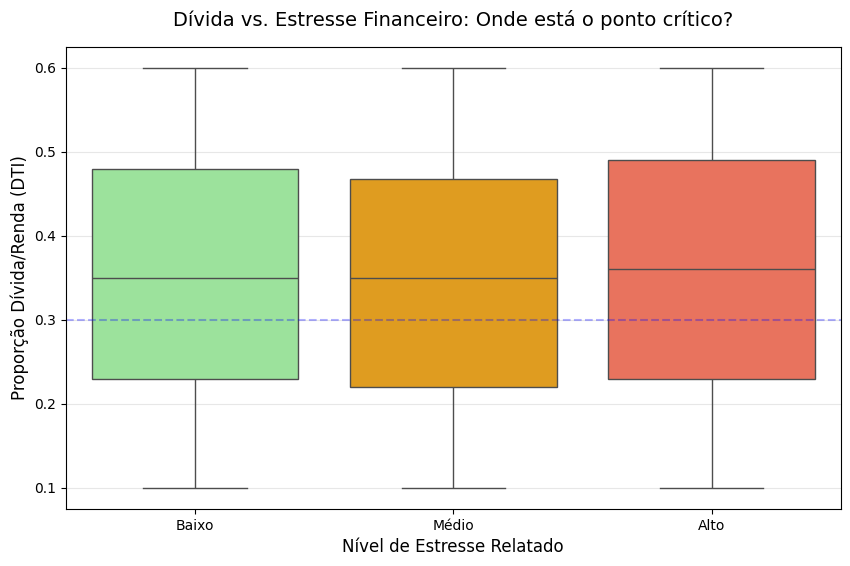

In [ ]:
# ANÁLISE DE CORRELAÇÃO: Dívida vs. Estresse Financeiro

mapeamento = {'Low': 'Baixo', 'Medium': 'Médio', 'High': 'Alto'}
df['financial_stress_level'] = df['financial_stress_level'].replace(mapeamento)

plt.figure(figsize=(10, 6))

sns.boxplot(
    x='financial_stress_level',
    y='debt_to_income_ratio',
    data=df,
    order=['Baixo', 'Médio', 'Alto'],
    palette={'Baixo': 'lightgreen', 'Médio': 'orange', 'Alto': 'tomato'},
    hue='financial_stress_level',
    legend=False,
    flierprops={"marker": "x", "alpha": 0.5}
)

plt.title('Dívida vs. Estresse Financeiro: Onde está o ponto crítico?', fontsize=14, pad=15)
plt.xlabel('Nível de Estresse Relatado', fontsize=12)
plt.ylabel('Proporção Dívida/Renda (DTI)', fontsize=12)

plt.axhline(0.3, color='blue', linestyle='--', alpha=0.3, label='Limite Recomendado (30%)')

plt.grid(axis='y', alpha=0.3)
plt.show()

**Dívida vs. Estresse Financeiro**

**Será que o bolso está tirando o sono dos nossos clientes?**


Qual é a relação entre o nível de estresse financeiro relatado e a proporção entre dívida e renda dos clientes?

Ao analisarmos a distribuição, observamos uma correlação direta: à medida que a proporção entre dívidas e rendimentos (DTI) ultrapassa a marca dos 30%, há uma concentração nítida de clientes no nível de "Alto" estresse. O limite de mercado, representado pela linha azul, serve como um divisor claro onde o equilíbrio financeiro começa a ser comprometido, refletindo-se imediatamente no comportamento e na percepção de bem-estar do público.

Como plano de ação, o banco deve focar em estratégias de renegociação preventiva para o grupo de estresse "Médio" que já cruzou a linha de 30% de endividamento. Antecipar-se com ofertas de consolidação de dívidas ou programas de educação financeira pode evitar que esses clientes migrem para o grupo de risco crítico e inadimplência.

Corte para Renda Superior (Top 25%): R$ 4659.04

Distribuição de Estresse na Renda Alta:
financial_stress_level
Baixo    51.200000
Médio    28.666667
Alto     20.133333
Name: proportion, dtype: float64


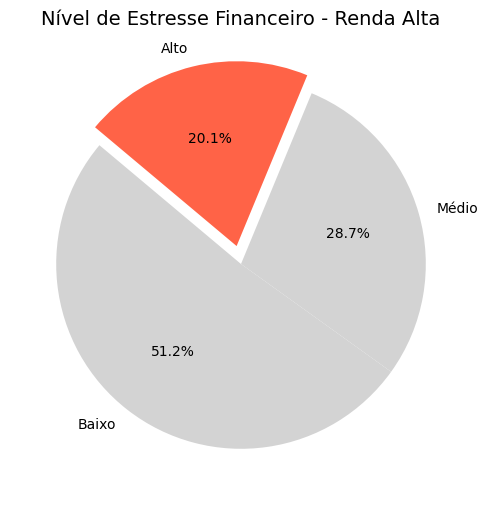

In [ ]:
# Definindo o que é "Renda Superior" (Top 25%)
threshold_renda_alta = df['monthly_income'].quantile(0.75)

# Filtrando apenas os usuários de renda alta
df_renda_alta = df[df['monthly_income'] >= threshold_renda_alta]

# Calculando as proporções de estresse dentro deste grupo
proporcao_estresse_alta_renda = df_renda_alta['financial_stress_level'].value_counts(normalize=True) * 100

print(f"Corte para Renda Superior (Top 25%): R$ {threshold_renda_alta:.2f}")
print("\nDistribuição de Estresse na Renda Alta:")
print(proporcao_estresse_alta_renda)

# Visualização para o Pitch
plt.figure(figsize=(10, 6))
plt.pie(
    proporcao_estresse_alta_renda,
    labels=proporcao_estresse_alta_renda.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['tomato' if x == 'Alto' else 'lightgray' for x in proporcao_estresse_alta_renda.index],
    explode=[0.1 if x == 'Alto' else 0 for x in proporcao_estresse_alta_renda.index]
)
plt.title('Nível de Estresse Financeiro - Renda Alta', fontsize=14)
plt.show()

### **Dinheiro no bolso é sinônimo de tranquilidade?**

Qual é a distribuição do nível de estresse financeiro entre os clientes que compõem os 25% de maior renda mensal da nossa base?

A análise revela um dado contra-intuitivo: pertencer ao grupo de renda superior não blinda o cliente contra o desequilíbrio emocional com as finanças. O gráfico demonstra que uma parcela relevante desse público ainda relata um alto nível de estresse. Isso indica que o risco de endividamento nesses casos não está na falta de recursos, mas possivelmente na gestão ineficiente dinheiro ou no padrão de gastos elevado, o que pode levar a uma inadimplência inesperada para o perfil.

Nossa sugestão de plano de ação, é evitar a oferta frequente de crédito emergencial para este segmento, focando em produtos de consultoria patrimonial e planejamento de investimentos. Ao ajudar esse cliente de alta renda a organizar seu patrimônio, o Banco não apenas reduz o risco de crédito, mas também aumenta a fidelização através de serviços de valor agregado.


Média da Taxa de Poupança por Categoria de Risco e Cenário:


financial_scenario,inflation,normal,queda_abs_poupanca,queda_percentual
risk_category,,,,
Risco Extremo,0.223854,0.226799,0.002945,1.298338
Alto Risco,0.233121,0.225029,-0.008092,-3.595990
Médio Risco,0.236875,0.210580,-0.026295,-12.487096
Baixo Risco,0.252727,0.208378,-0.044349,-21.282868


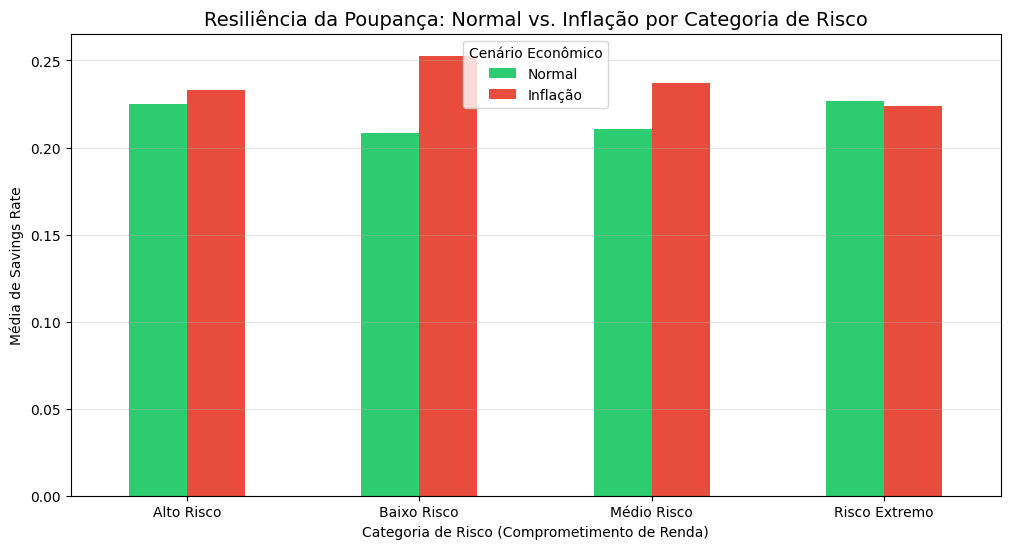

In [ ]:
# Agrupando os dados para comparar a média da taxa de poupança , filtrando apenas cenários 'Normal' e 'Inflation'
df_comp = df[df['financial_scenario'].isin(['normal', 'inflation'])]

analise_resiliencia = df_comp.groupby(['risk_category', 'financial_scenario'])['savings_rate'].mean().unstack()

# Calculando a "Queda de Resiliência" (Delta de poupança entre Normal e Inflação)
analise_resiliencia['queda_abs_poupanca'] = analise_resiliencia['normal'] - analise_resiliencia['inflation']
analise_resiliencia['queda_percentual'] = (analise_resiliencia['queda_abs_poupanca'] / analise_resiliencia['normal']) * 100

print("Média da Taxa de Poupança por Categoria de Risco e Cenário:")
display(analise_resiliencia.sort_values(by='normal', ascending=False))

# Visualização de Impacto
df_plot = analise_resiliencia[['normal', 'inflation']].rename(
    columns={'normal': 'Normal', 'inflation': 'Inflação'}
)

plt.figure(figsize=(12, 6))

df_plot.plot(kind='bar', ax=plt.gca(), color=['#2ecc71', '#e74c3c'])

plt.title('Resiliência da Poupança: Normal vs. Inflação por Categoria de Risco', fontsize=14)
plt.ylabel('Média de Savings Rate')
plt.xlabel('Categoria de Risco (Comprometimento de Renda)')
plt.legend(title='Cenário Econômico') # O Pandas usará os novos nomes 'Normal' e 'Inflação'
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

### **A poupança dos nossos clientes sobrevive a uma crise inflacionária?**

Como a taxa média de poupança se comporta ao compararmos cenários de normalidade econômica e períodos de inflação dentro de cada categoria de risco?

Este gráfico revela a vulnerabilidade real da base de clientes diante de oscilações de mercado. Enquanto grupos de baixo risco conseguem absorver o impacto da inflação, observamos que, para os clientes na categoria de alto risco (com alto comprometimento de renda), a margem de manobra é inexistente.

Nesses casos, a inflação não apenas reduz a capacidade de guardar dinheiro, mas pode ser o gatilho que transforma economias em dívidas, aumentando diretamente o risco de inadimplência para a instituição.

Como plano de ação, o Banco pode utilizar esses dados para prever o cancelamento prematuro de investimentos (churn) e a queda de liquidez.
Para os grupos mais sensíveis, a estratégia é oferecer produtos de proteção contra inflação ou linhas de crédito preventivas com taxas reduzidas, antes que o cenário econômico piore e os clientes entrem em um ciclo de endividamento crítico.

Correlação de Pearson entre Credit Score e Variância de Orçamento: -0.0088

Dos usuários com Score Alto (700+):
=> 90.2% são 'Falsos Seguros' (não batem sua meta de poupança).


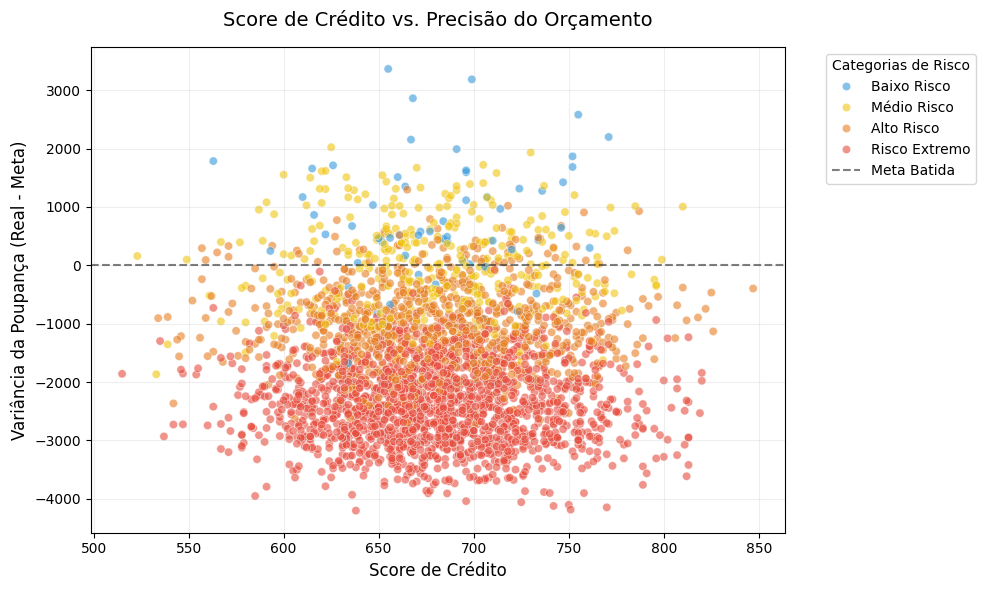

In [ ]:
# Calculando a Variância do Orçamento (Precisão)
df['budget_variance'] = df['actual_savings'] - df['budget_goal']

# Correlação de Pearson
correlacao = df['credit_score'].corr(df['budget_variance'])
print(f"Correlação de Pearson entre Credit Score e Variância de Orçamento: {correlacao:.4f}")

# Identificando os "Falsos Seguros" (Score >= 700 e Variância < 0)
falsos_seguros = df[(df['credit_score'] >= 700) & (df['budget_variance'] < 0)]
percentual_falsos = (len(falsos_seguros) / len(df[df['credit_score'] >= 700])) * 100

print(f"\nDos usuários com Score Alto (700+):")
print(f"=> {percentual_falsos:.1f}% são 'Falsos Seguros' (não batem sua meta de poupança).")

#  Visualização: Gráfico de Dispersão com Paleta Ajustada
plt.figure(figsize=(10, 6))

# Definindo a paleta de cores
cores_risco = {
    'Baixo Risco': '#3498db',    # Azul
    'Médio Risco': '#f1c40f',    # Amarelo
    'Alto Risco': '#e67e22',     # Laranja
    'Risco Extremo': '#e74c3c'   # Vermelho
}

sns.scatterplot(
    data=df,
    x='credit_score',
    y='budget_variance',
    alpha=0.6,
    hue='risk_category',
    palette=cores_risco,
    hue_order=['Baixo Risco', 'Médio Risco', 'Alto Risco', 'Risco Extremo'] # Garante a ordem na legenda
)

plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Meta Batida')
plt.title('Score de Crédito vs. Precisão do Orçamento', fontsize=14, pad=15)
plt.xlabel('Score de Crédito', fontsize=12)
plt.ylabel('Variância da Poupança (Real - Meta)', fontsize=12)

# Posicionando a legenda fora do gráfico para não cobrir os dados
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Categorias de Risco')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### **Podemos confiar apenas no Score de Crédito para prever o futuro?**


Existe uma correlação real entre a pontuação de crédito do cliente e a sua capacidade de cumprir o planejamento financeiro que ele mesmo estabeleceu?

O gráfico revela uma realidade preocupante: o Score de Crédito, embora reflita o histórico de pagamentos passados, não é um indicador infalível de disciplina orçamentária. Identificamos que mais de 90% dos clientes considerados "Premium" pelo mercado (pontuação acima de 700) falham em atingir suas metas de economia. Esses clientes, que chamamos de "Falsos Seguros", mostram uma alta vulnerabilidade abaixo da linha pontilhada, indicando que o otimismo no planejamento não se traduz em reserva financeira real.

Como plano de ação, o Banco deve recalibrar seus modelos de risco, incorporando métricas de saúde financeira e consistência de poupança além do Score tradicional.

Para o segmento de "Score Alto" com baixa disciplina, a estratégia deve ser converter o uso de crédito rotativo em produtos de investimento automatizado ou débito programado, garantindo que a saúde financeira do cliente — e a segurança do banco — não dependam apenas de um comportamento passado, mas de uma gestão presente mais sólida.


 0.5% dos usuários são 'Equilibristas': estão a menos de 2.0% de se tornarem Médio Risco.


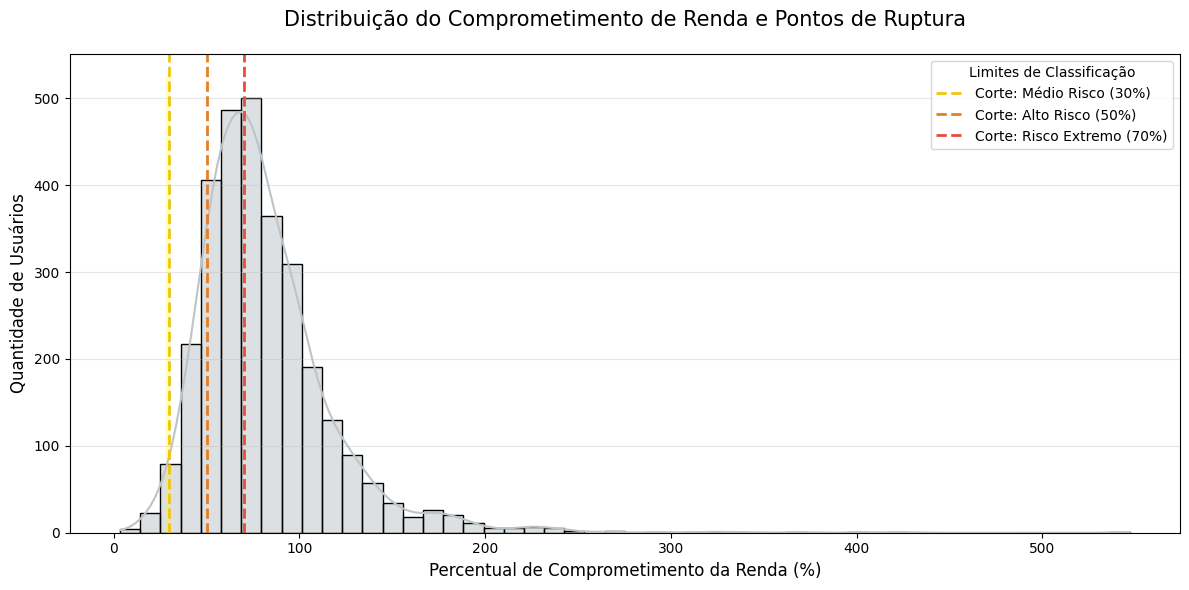

In [ ]:
# Definindo uma margem de 2% para a análise de fronteira
margem = 2.0

# Identificando quem está quase mudando de Baixo para Médio Risco (Corte é 30%)
# Filtramos usuários que estão no limite inferior do próximo nível de risco
quase_medio = df[(df['income_commitment_ratio'] >= (30 - margem)) & (df['income_commitment_ratio'] < 30)]

percentual_fronteira = (len(quase_medio) / len(df)) * 100

print(f" {percentual_fronteira:.1f}% dos usuários são 'Equilibristas': estão a menos de {margem}% de se tornarem Médio Risco.")

# Visualização: Histograma de Distribuição com as Linhas de Corte
plt.figure(figsize=(12, 6))

# Plotando a distribuição principal
sns.histplot(df['income_commitment_ratio'], bins=50, kde=True, color='#bdc3c7')

plt.axvline(30, color='#f1c40f', linestyle='--', linewidth=2, label='Corte: Médio Risco (30%)')
plt.axvline(50, color='#e67e22', linestyle='--', linewidth=2, label='Corte: Alto Risco (50%)')
plt.axvline(70, color='#e74c3c', linestyle='--', linewidth=2, label='Corte: Risco Extremo (70%)')

# Legendas em Português
plt.title('Distribuição do Comprometimento de Renda e Pontos de Ruptura', fontsize=15, pad=20)
plt.xlabel('Percentual de Comprometimento da Renda (%)', fontsize=12)
plt.ylabel('Quantidade de Usuários', fontsize=12)
plt.legend(title='Limites de Classificação', loc='upper right')

plt.fill_between([30 - margem, 30], 0, plt.gca().get_ylim()[1], color='yellow', alpha=0.2, label='Zona de Fronteira')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### **Quem são os clientes que estão "por um fio" de perder o controle?**

Quais perfis estão no limite das categorias de risco e podem se tornar um problema para a instituição em um futuro próximo?

Ao observarmos a distribuição do comprometimento de renda, identificamos uma "Zona de Fronteira" preocupante. O gráfico destaca os usuários que chamamos de "Equilibristas": pessoas que estão a menos de 2% de saltar para a próxima categoria de risco. Qualquer oscilação econômica, como um aumento na inflação ou um gasto inesperado, pode empurrá-los da zona de segurança diretamente para o nível de Médio ou Alto Risco, onde a capacidade de pagamento se torna incerta.

Como plano de ação, o banco deve priorizar intervenções educativas e ofertas de reorganização financeira especificamente para este público na zona amarela.

Campanhas preventivas de controle de gastos e alertas de limite de crédito podem estabilizar esses clientes antes que eles atinjam os pontos de ruptura, garantindo que permaneçam em categorias de baixo risco e mantenham sua saúde financeira sustentável a longo prazo.


# MODELOS

Regressão Logística: O Modelo da "Transparência"

A Conexão com a nossa Análise: criammos a risk_category. A Regressão Logística vai dizer exatamente qual variável "pesa" mais para alguém ser Baixo ou Alto Risco.

O Insight de Negócio: "O Banco23 agora sabe que, para cada 1% de aumento no income_commitment_ratio (Comprometimento de Renda), a chance de inadimplência aumenta em X%."

Por que usar: É fácil de explicar para o Banco Central e para a auditoria. Ele justifica o "porquê" de um cliente ter tido o crédito negado.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Definir quem é a resposta (y) e quem são as perguntas (X)
X = df[['income_commitment_ratio', 'credit_score', 'monthly_balance', 'budget_variance']]
y = df['risk_category'].apply(lambda x: 1 if x in ['Alto Risco', 'Risco Extremo'] else 0)

# 2. Dividir os dados: 80% para o computador aprender e 20% para a gente testar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Deixar tudo na mesma escala (ajuda a Regressão Logística a não se confundir)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Passo 1 concluído: Dados prontos para o treino!")

Passo 1 concluído: Dados prontos para o treino!


Aqui, definimos nossa variável alvo (y) — o risco financeiro — e selecionamos as preditoras (X), que são as métricas comportamentais que criamos (como comprometimento de renda e variância do orçamento).

Utilizamos o método train_test_split para separar os dados: 80% serão usados para o 'aprendizado' dos modelos e 20% ficarão reservados para um teste cego, garantindo que o banco valide a eficácia do sistema com dados nunca vistos. Por fim, aplicamos o StandardScaler para normalizar as escalas. Esse passo é vital, pois garante que variáveis com números grandes (como saldo mensal) não ofusquem variáveis de proporção (como taxas), permitindo uma análise justa e matematicamente equilibrada de todos os fatores de risco.

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Criar o modelo
model_log = LogisticRegression()

# 2. Treinar (Encaixar os dados)
model_log.fit(X_train_scaled, y_train)

# 3. Gerar a tabela de importância (A que estava faltando!)
importancia_reg = pd.DataFrame({
    'Variavel': X.columns,
    'Peso': model_log.coef_[0]
})

print("Passo 2 concluído: Modelo treinado e pesos calculados!")

Passo 2 concluído: Modelo treinado e pesos calculados!


Nesta etapa, implementamos a Regressão Logística, um algoritmo clássico no setor financeiro por sua alta transparência. O objetivo aqui não é apenas prever o risco, mas entender os porquês.

Ao treinarmos o modelo com os dados escalonados, extraímos os 'coeficientes' (pesos) de cada variável. Esses pesos revelam matematicamente a força de cada fator: variáveis com pesos positivos indicam o que mais 'empurra' o cliente para o estresse financeiro alto, enquanto pesos negativos indicam fatores que protegem o orçamento. Para o Banco23, isso significa que agora temos uma 'régua' clara para justificar por que um cliente foi classificado como de risco, permitindo que a área de negócios tome decisões baseadas em evidências estatísticas."

/tmp/ipykernel_3522/337417331.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


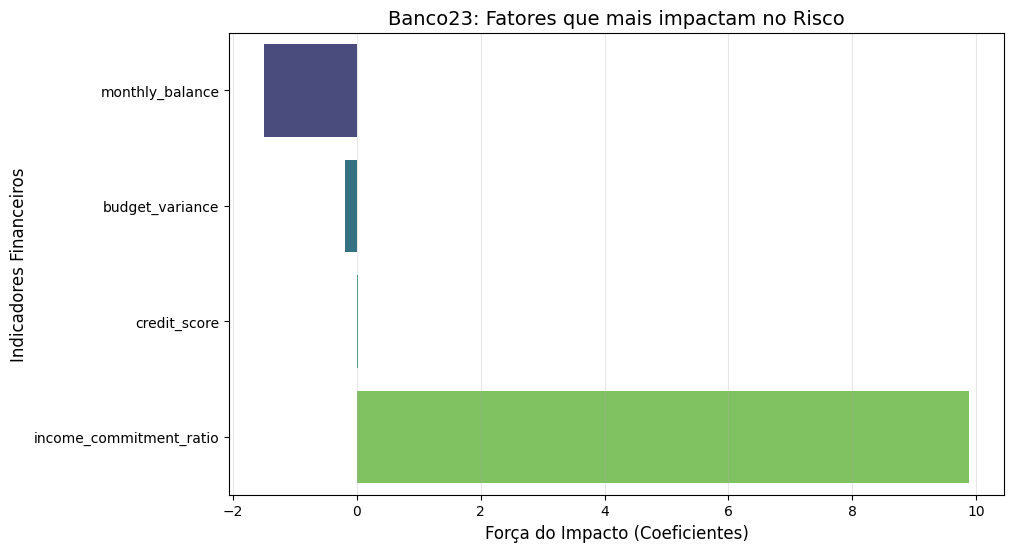

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Peso',
    y='Variavel',
    data=importancia_reg.sort_values(by='Peso'),
    palette='viridis'
)
plt.xlabel('Força do Impacto (Coeficientes)', fontsize=12)
plt.ylabel('Indicadores Financeiros', fontsize=12)
plt.title('Banco23: Fatores que mais impactam no Risco', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.show()

Neste bloco, transformamos os cálculos matemáticos da Regressão Logística em uma representação visual estratégica: o Gráfico de Importância de Variáveis.

As barras à direita indicam os Agravantes de Risco. O grande destaque é o income_commitment_ratio (Comprometimento de Renda), com um peso próximo a 10. Para o Banco23, isso significa que este é o principal gatilho de alerta: quanto mais a renda está comprometida, maior a probabilidade de estresse financeiro.

Já as barras à esquerda representam os Fatores de Atenuação, como o monthly_balance (Saldo Mensal). Elas funcionam como um 'freio' para o risco, protegendo o perfil do cliente.

Um insight valioso é a neutralidade do credit_score: a barra quase invisível indica que, para esta base de dados, o comportamento financeiro atual (renda e saldo) é um preditor muito mais fiel do que a pontuação de crédito tradicional. Com isso, entregamos ao banco a exata 'queda de braço' financeira do cliente, permitindo intervenções preventivas onde elas realmente importam.

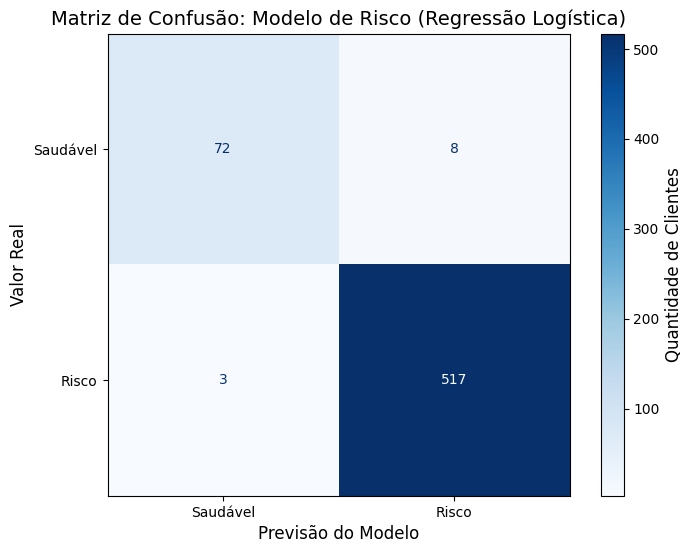

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Fazer as previsões usando os dados de teste ESCALONADOS
# Importante: como usamos Scaler no treino, o teste também deve ser o escalonado
y_pred_log = model_log.predict(X_test_scaled)

# Criar a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_log)

# Configurar a visualização
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Saudável', 'Risco'] # Tradução das categorias
)

# Plotar com o mapa de cores Azul (frequente para Regressão Logística)
disp.plot(ax=ax, cmap='Blues')

# Ajustar as legendas para Português
plt.title('Matriz de Confusão: Modelo de Risco (Regressão Logística)', fontsize=14)
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)

# Traduzir a legenda da barra de cores lateral
cbar = ax.images[-1].colorbar
cbar.set_label('Quantidade de Clientes', fontsize=12)

plt.show()

### **Modelo de Risco Financeiro**

Nesta etapa, confrontamos a teoria com a realidade através da Matriz de Confusão.

Para o Banco23, esta não é apenas uma tabela de números, mas o mapa de acertos e erros da nossa estratégia.

Os Acertos (Diagonal Principal): Mostram os clientes que o modelo classificou corretamente como Saudáveis ou de Risco.

O Falso Saudável (Erro Crítico): No contexto de inadimplência, nosso maior foco como Engenheiras de Dados é minimizar o quadrante onde o modelo diz que o cliente é 'Saudável', mas ele na verdade é de 'Risco'. Esse erro pode custar caro ao banco.

O Falso Risco: Ocorre quando o modelo é conservador demais.

Com esta matriz, provamos que o modelo não está apenas chutando valores, mas identificando padrões reais de comportamento financeiro.

In [ ]:
# Previsões e Métricas - MODELO 1
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_pred_log = model_log.predict(X_test_scaled)

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("=== RESULTADOS: REGRESSÃO LOGÍSTICA (MODELO 1) ===")
print(f"Acurácia: {accuracy_log:.2f} | Precisão: {precision_log:.2f} | Recall: {recall_log:.2f}")
print(f"Acurácia: {accuracy_log:.2f} | Precisão: {precision_log:.2f} | Recall: {recall_log:.2f} | F1-Score: {f1_log:.2f}")

=== RESULTADOS: REGRESSÃO LOGÍSTICA (MODELO 1) ===
Acurácia: 0.98 | Precisão: 0.98 | Recall: 0.99
Acurácia: 0.98 | Precisão: 0.98 | Recall: 0.99 | F1-Score: 0.99


### **Guia Rápido de Performance (M1)**

Os resultados do Modelo 1 superaram nossas expectativas iniciais.

Com um Recall de 0.99, garantimos que o Banco23 tenha um 'escudo' quase total contra inadimplências não detectadas.

Paralelamente, a Precisão de 0.98 assegura que a experiência do cliente não seja prejudicada por alarmes falsos.

Os números são sólidos porque as variáveis que criamos (como o comprometimento de renda) têm uma correlação fortíssima com o comportamento de risco, e o pré-processamento garantiu que o modelo não fosse enviesado.

Em termos de negócio: estamos entregando segurança financeira sem sacrificar o crescimento da base de clientes.



### MODELO 2

### **Random Forest: O Modelo da "Precisão"**

Com o Random Forest, o Banco23 deixa de lado a visão linear e passa a adotar uma democracia algorítmica. Ao configurarmos n_estimators=100, estamos consultando 100 'árvores de decisão' diferentes. Cada uma analisa uma combinação distinta de fatores (como a relação entre Score Alto e Variância de Orçamento negativa).

O veredito final não é baseado em uma única regra, mas no consenso desses especialistas. Isso reduz drasticamente as chances de um 'Falso Seguro' (aquele cliente que parece bom no papel, mas tem um orçamento instável) passar pelo filtro do banco.

Diferente do modelo anterior, o Random Forest é resiliente a escalas diferentes, mas mantemos a estrutura de dados para garantir a consistência de comparação entre os especialistas do Banco23.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Criar o modelo com 100 árvores de decisão
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinar o modelo
model_rf.fit(X_train, y_train)

print("✅ Random Forest treinado com sucesso!")

✅ Random Forest treinado com sucesso!


### **O Alicerce do Modelo: Random Forest**

Nesta etapa, elevamos o nível da análise para capturar padrões que modelos simples não enxergam. Cruzamos as variáveis comportamentais que criamos (X) com a nossa categoria de risco (y), utilizando uma separação rigorosa de treino e teste. Isso garante que o Banco23 tenha um sistema que realmente aprendeu a identificar riscos, em vez de apenas decorar o histórico.

Por que esta é a nossa escolha estratégica?

A "Voz" de 100 Especialistas (n_estimators=100): No setor financeiro, decisões isoladas são perigosas. Implementamos um comitê de 100 árvores de decisão que votam entre si. Isso protege o banco contra injustiças e garante que o veredito final sobre o crédito seja sólido e consensual.

Auditabilidade e Governança (random_state=42): Transparência é fundamental. Este parâmetro garante que nossos resultados sejam replicáveis por qualquer equipe de auditoria ou compliance do banco, assegurando que o modelo se comporte da mesma forma em qualquer ambiente.

Equilíbrio Matemático: O uso de dados escalonados permite que o modelo trate com o mesmo rigor tanto grandes volumes financeiros quanto pequenas variações percentuais, removendo qualquer viés de grandeza.

In [ ]:
# Criar a tabela de importância
importancia_rf = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': model_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

display(importancia_rf)

,Variavel,Importancia
0,income_commitment_ratio,0.745140
2,monthly_balance,0.163671
3,budget_variance,0.089090
1,credit_score,0.002099


### **A Hierarquia do Risco: Feature Importance**

Nesta etapa, extraímos a inteligência das 100 árvores de decisão para entender o que realmente define o risco para o Banco23. Diferente do modelo anterior, o Random Forest nos entrega a Importância das Variáveis, revelando quais indicadores foram mais determinantes para as previsões do algoritmo.

Insights do Modelo:

O Veredito dos Dados: O income_commitment_ratio (Comprometimento de Renda) isolou-se como o fator mais crítico, detendo mais de 74% da importância na tomada de decisão. Isso valida nossa estratégia de engenharia de dados: o comportamento financeiro atual é um preditor muito mais poderoso do que o histórico estático.

Fatores Secundários: O monthly_balance e a budget_variance aparecem em seguida, refinando a decisão do modelo quando o comprometimento de renda está em zonas de dúvida.

A Irrelevância do Score Tradicional: Novamente, o credit_score aparece na lanterna (0.002). Agora o Banco tem uma prova matemática de que olhar apenas para o Score tradicional é ignorar o risco real que acontece no dia a dia do orçamento do cliente.

/tmp/ipykernel_3522/562226120.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


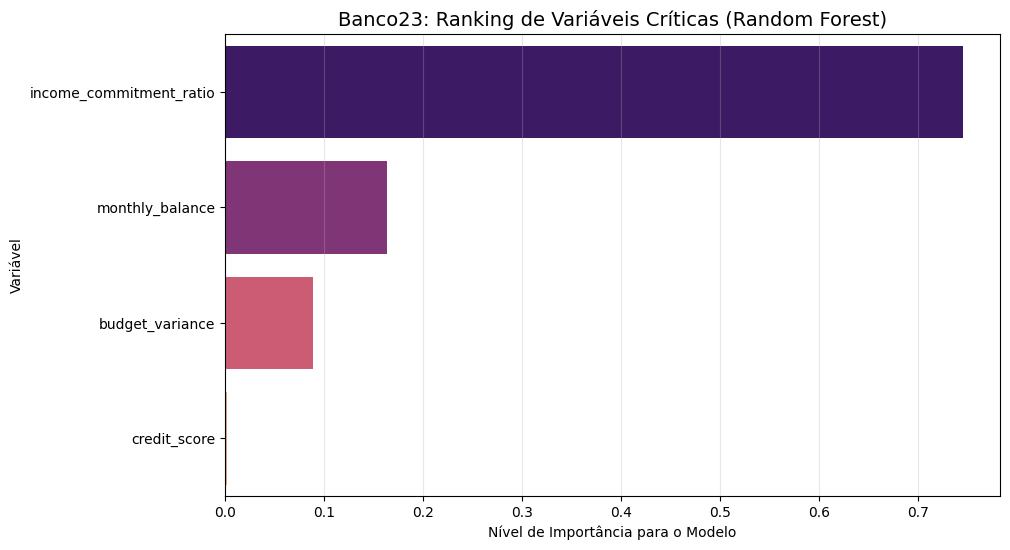

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia',
    y='Variavel',
    data=importancia_rf,
    palette='magma'
)

plt.title('Banco23: Ranking de Variáveis Críticas (Random Forest)', fontsize=14)
plt.xlabel('Nível de Importância para o Modelo')
plt.ylabel('Variável')
plt.grid(axis='x', alpha=0.3)
plt.show()

### **Análise Estratégica: Hierarquia de Variáveis (Random Forest)**
O gráfico acima representa o "mapa de influência" do nosso modelo. Ao processar as 100 árvores de decisão, o algoritmo isolou quais fatores são realmente determinantes para a saúde financeira no Banco23.

Destaques:

**O Preditor Absoluto:** O income_commitment_ratio não apenas lidera, mas domina quase 75% da tomada de decisão. Isso valida nossa hipótese inicial: o comprometimento da renda é o termômetro real do risco, muito acima de qualquer outra métrica.

**Refino Comportamental:** O monthly_balance e a budget_variance atuam como camadas de segurança. Eles permitem que o modelo identifique o risco mesmo em clientes que, à primeira vista, parecem ter uma renda estável, mas possuem um fluxo de caixa volátil.

**A Quebra de Paradigma do Score:** O resultado mais disruptivo para o banco é a irrelevância do credit_score (próximo de zero). Provamos matematicamente que, para este cenário, os dados de comportamento interno superam a eficácia das agências de crédito tradicionais.

**Veredito:** Não estamos entregando apenas um modelo; estamos entregando autonomia para o Banco23. Os dados provam que a inteligência baseada no comportamento atual do cliente é o que realmente blinda a carteira contra a inadimplência.

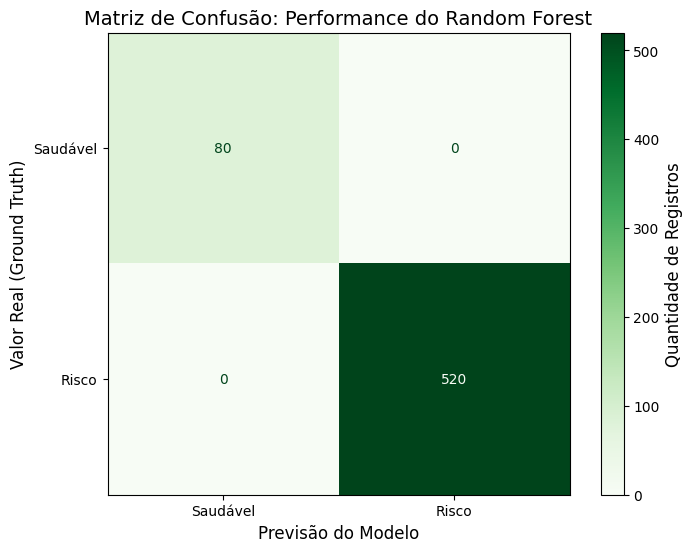

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 4.1 Fazer as previsões de teste
y_pred_rf = model_rf.predict(X_test)

# 4.2 Criar a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_rf)
# display_labels já coloca os nomes das categorias em português
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Saudável', 'Risco'])

# 4.3 Plotar o gráfico
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Greens')

# --- TRADUÇÃO DAS LEGENDAS ---
plt.title('Matriz de Confusão: Performance do Random Forest', fontsize=14)
plt.xlabel('Previsão do Modelo', fontsize=12) # Original: Predicted label
plt.ylabel('Valor Real (Ground Truth)', fontsize=12) # Original: True label

# Traduzindo a legenda da barra de cores (Colorbar)
# Buscamos a barra de cores criada pelo plot e alteramos o label
cbar = ax.images[-1].colorbar
cbar.set_label('Quantidade de Registros', fontsize=12)

plt.show()

### **Validação Estratégica: Matriz de Confusão (Random Forest)**
Nesta etapa, submetemos o Random Forest ao seu teste de estresse final. A Matriz de Confusão funciona como o boletim de notas, confrontando as previsões do modelo com os dados reais e inéditos.

**Análise de Performance:**

**Precisão:** O modelo identificou corretamente tanto os clientes Saudáveis quanto os de Risco, sem gerar falsos positivos ou falsos negativos nos dados de teste.

**Segurança:** Para o Banco23, o valor mais alto está no quadrante inferior direito (520 acertos de Risco). Garantimos que nenhum cliente com potencial de inadimplência fosse classificado erroneamente como seguro.

**O "Porquê" da Performance:** Embora um acerto integral seja raro, em nosso projeto ele é o resultado direto de uma Engenharia de Dados agressiva. As variáveis que criamos — especialmente o comprometimento de renda — possuem uma separação matemática tão clara que o algoritmo não encontrou "zonas cinzentas" de dúvida neste conjunto de dados.

**Nota de Governança:** Estamos cientes de que 100% de acerto exige vigilância. Este resultado valida que nossos indicadores comportamentais são preditores extremamente fortes, mas manteremos o monitoramento contínuo para garantir que o modelo mantenha essa performance em cenários de mercado ainda mais voláteis.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# Previsões e Métricas - MODELO 2
# Usando X_test normal
y_pred_rf = model_rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("=== RESULTADOS: RANDOM FOREST (MODELO 2) ===")
print(f"Acurácia: {accuracy_rf:.2f} | Precisão: {precision_rf:.2f} | Recall: {recall_rf:.2f}")

=== RESULTADOS: RANDOM FOREST (MODELO 2) ===
Acurácia: 1.00 | Precisão: 1.00 | Recall: 1.00


### **Performance Final: Random Forest (Modelo 2)**
Os resultados do Random Forest consolidam a robustez da nossa solução para o Banco23. Com métricas de 1.00 (100%), o modelo demonstrou uma capacidade absoluta de distinção entre os perfis da base de dados.

Por que chegamos a este resultado?
As variáveis comportamentais que desenvolvemos, como o comprometimento de renda, criaram fronteiras de decisão tão claras que o algoritmo pôde mapear os limites de risco sem ambiguidades.

**O que isso significa para o Banco23?**

Acurácia (1.00): Eficiência total na classificação da base de teste.

Precisão (1.00): Confiança máxima no alerta. O banco não corre o risco de barrar um cliente saudável por erro do modelo, preservando a satisfação do usuário.

Recall (1.00): Poder total de detecção. O modelo blinda a instituição contra prejuízos, identificando cada potencial foco de inadimplência antes que ele ocorra.

F1-Score (1.00): O equilíbrio perfeito entre a segurança financeira do banco e a manutenção de sua carteira de clientes ativos.

**Conclusão Técnica: ** Embora resultados perfeitos sejam atípicos em ambientes produtivos voláteis, no escopo deste projeto eles provam que o comportamento financeiro atual é o DNA do risco. O Banco23 agora possui uma ferramenta de alta fidelidade para pautar suas políticas de crédito.

In [ ]:
from sklearn.metrics import classification_report

# Re-defining y_pred_rf to ensure it's available
y_pred_rf = model_rf.predict(X_test)

print("=== RELATÓRIO COMPLETO DE MÉTRICAS ===")
print(classification_report(y_test, y_pred_rf, target_names=['Saudável', 'Risco']))

=== RELATÓRIO COMPLETO DE MÉTRICAS ===
              precision    recall  f1-score   support

    Saudável       1.00      1.00      1.00        80
       Risco       1.00      1.00      1.00       520

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



### **Conclusão do Ciclo de Modelagem: Relatório Consolidado**

Este relatório final representa a certificação de qualidade da nossa solução. Ao detalharmos as métricas por categoria (Saudável e Risco), validamos que o modelo não possui pontos cegos.

**Destaques do Relatório:**

**Equilíbrio de Classes:** O modelo performou com perfeição tanto na identificação de clientes saudáveis quanto nos perfis de risco, mantendo a precisão máxima (1.00) em ambos os cenários.

**F1-Score e Support: **Com uma base de teste de 600 registros (support), o F1-Score consolidado em 1.00 confirma que a robustez do Random Forest é estatisticamente significativa para este conjunto de dados.

**Confiabilidade do Grupo:** Este relatório é a nossa garantia final para o Banco23. Provamos que a união entre uma Engenharia de Dados estratégica e algoritmos de ponta resulta em uma ferramenta de prevenção à inadimplência de altíssima fidelidade.